# CNC Tool Wear Analysis

## 1. Data Loading

In [167]:
import pandas as pd
from sqlalchemy  import create_engine

In [ ]:
username = "postgres"
password = "YOUR_PASSWORD"
host = "localhost"
port = "5432"
database = "cnc_tool_wear_analysis"

In [169]:
connection_string = f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"

In [170]:
engine=create_engine(connection_string)

In [171]:
operations_df=pd.read_sql("SELECT * FROM operations",engine)
wear_measurements_df=pd.read_sql("SELECT * FROM wear_measurements",engine)
operation_tools_df=pd.read_sql("SELECT * FROM operation_tools",engine)
tools_df=pd.read_sql("SELECT * FROM tools",engine)
tool_positions_df=pd.read_sql("SELECT * FROM tool_positions",engine)
work_orders_df=pd.read_sql("SELECT * FROM work_orders",engine)

## 2. Data Preparation


In [172]:
operation_positions_df=operation_tools_df.merge(tool_positions_df,on="tool_id",how="left")

In [173]:
operation_positions_df.head()

,operation_id,tool_id,position_id,position_number
0,0000,T008,P027,1
1,0000,T008,P028,2
2,0000,T008,P029,3
3,0001,T001,P001,1
4,0001,T001,P002,2


In [174]:
analysis_base_df=operation_positions_df.merge(operations_df,on="operation_id",how="left")

In [175]:
analysis_base_df.head()

,operation_id,tool_id,position_id,position_number,work_order_id,machine_id,operator_id,parts,cutting_time,rpm
0,0000,T008,P027,1,W007,M002,OP001,68,1.80,2114
1,0000,T008,P028,2,W007,M002,OP001,68,1.80,2114
2,0000,T008,P029,3,W007,M002,OP001,68,1.80,2114
3,0001,T001,P001,1,W006,M004,OP004,61,3.17,3491
4,0001,T001,P002,2,W006,M004,OP004,61,3.17,3491


In [176]:
analysis_base_df.groupby(["operation_id","tool_id"]).sample(n=1)

,operation_id,tool_id,position_id,position_number,work_order_id,machine_id,operator_id,parts,cutting_time,rpm
1,0000,T008,P028,2,W007,M002,OP001,68,1.80,2114
5,0001,T001,P003,3,W006,M004,OP004,61,3.17,3491
7,0001,T007,P024,2,W006,M004,OP004,61,3.17,3491
11,0002,T007,P024,2,W002,M001,OP006,36,2.12,2198
16,0003,T004,P014,3,W006,M005,OP002,93,8.10,1160
...,...,...,...,...,...,...,...,...,...,...
716,0098,T005,P015,1,W004,M007,OP004,33,2.75,2174
713,0098,T009,P030,1,W004,M007,OP004,33,2.75,2174
727,0099,T001,P001,1,W005,M003,OP002,33,1.65,2788
722,0099,T004,P014,3,W005,M003,OP002,33,1.65,2788


In [177]:
analysis_base_df = operation_positions_df.merge(
    wear_measurements_df,
    on=["operation_id", "position_id"],
    how="left"
)

In [178]:
analysis_base_df.head()

,operation_id,tool_id,position_id,position_number,measurement_id,wear_mm,visual_condition,measurement_date
0,0000,T008,P027,1,203.0,0.088,Normal,2026-01-01
1,0000,T008,P028,2,1.0,0.100,Slight Whitening,2026-01-01
2,0000,T008,P029,3,NaN,NaN,NaN,NaN
3,0001,T001,P001,1,NaN,NaN,NaN,NaN
4,0001,T001,P002,2,2.0,0.107,Slight Whitening,2026-01-02


In [179]:
operation_positions_df = operation_positions_df.groupby(
    ["operation_id", "tool_id"]
).sample(n=1)

In [180]:
operation_positions_df.groupby(
    ["operation_id", "tool_id"]
).size()

operation_id  tool_id
0000          T008       1
0001          T001       1
              T007       1
0002          T007       1
0003          T004       1
                        ..
0098          T005       1
              T009       1
0099          T001       1
              T004       1
              T007       1
Length: 202, dtype: int64

In [181]:
analysis_base_df = operation_positions_df.merge(
    wear_measurements_df,
    on=["operation_id", "position_id"],
    how="left"
)

In [182]:
analysis_base_df.shape

(223, 8)

In [183]:
analysis_base_df.isna().sum()

operation_id         0
tool_id              0
position_id          0
position_number      0
measurement_id      99
wear_mm             99
visual_condition    99
measurement_date    99
dtype: int64

In [184]:
wear_measurements_df.shape

(404, 6)

In [185]:
wear_measurements_df[["operation_id", "position_id"]].head(10)

,operation_id,position_id
0,0000,P028
1,0001,P002
2,0001,P024
3,0002,P025
4,0003,P013
5,0003,P020
6,0004,P015
7,0005,P003
8,0005,P028
9,0005,P031


In [186]:
operation_positions_df[["operation_id", "position_id"]].head(10)

,operation_id,position_id
2,0000,P029
4,0001,P002
6,0001,P023
10,0002,P023
15,0003,P013
19,0003,P021
21,0004,P015
31,0005,P001
26,0005,P028
30,0005,P032


In [187]:
analysis_base_df = wear_measurements_df.merge(
    tool_positions_df,
    on="position_id",
    how="left"
)

In [188]:
analysis_base_df.head()

,measurement_id,position_id,operation_id,wear_mm,visual_condition,measurement_date,tool_id,position_number
0,1,P028,0000,0.100,Slight Whitening,2026-01-01,T008,2
1,2,P002,0001,0.107,Slight Whitening,2026-01-02,T001,2
2,3,P024,0001,0.104,Slight Whitening,2026-01-03,T007,2
3,4,P025,0002,0.086,Normal,2026-01-04,T007,3
4,5,P013,0003,0.202,Visible Wear,2026-01-05,T004,2


In [189]:
analysis_df = analysis_base_df.merge(
    operations_df,
    on="operation_id",
    how="left"
)

In [190]:
analysis_df.head()

,measurement_id,position_id,operation_id,wear_mm,visual_condition,measurement_date,tool_id,position_number,work_order_id,machine_id,operator_id,parts,cutting_time,rpm
0,1,P028,0000,0.100,Slight Whitening,2026-01-01,T008,2,W007,M002,OP001,68,1.80,2114
1,2,P002,0001,0.107,Slight Whitening,2026-01-02,T001,2,W006,M004,OP004,61,3.17,3491
2,3,P024,0001,0.104,Slight Whitening,2026-01-03,T007,2,W006,M004,OP004,61,3.17,3491
3,4,P025,0002,0.086,Normal,2026-01-04,T007,3,W002,M001,OP006,36,2.12,2198
4,5,P013,0003,0.202,Visible Wear,2026-01-05,T004,2,W006,M005,OP002,93,8.10,1160


In [191]:
analysis_df.shape

(404, 14)

In [192]:
analysis_df.isna().sum()

measurement_id      0
position_id         0
operation_id        0
wear_mm             0
visual_condition    0
measurement_date    0
tool_id             0
position_number     0
work_order_id       0
machine_id          0
operator_id         0
parts               0
cutting_time        0
rpm                 0
dtype: int64

In [193]:
analysis_df.dtypes

measurement_id        int64
position_id             str
operation_id            str
wear_mm             float64
visual_condition        str
measurement_date     object
tool_id                 str
position_number       int64
work_order_id           str
machine_id              str
operator_id             str
parts                 int64
cutting_time        float64
rpm                   int64
dtype: object

In [194]:
analysis_df["wear_mm"].describe().round(2)

count    404.00
mean       0.13
std        0.04
min        0.04
25%        0.10
50%        0.13
75%        0.16
max        0.21
Name: wear_mm, dtype: float64

In [195]:
analysis_df.groupby("wear_mm")["parts"]

In [196]:
analysis_df["cutting_time"].describe().round(2)

count    404.00
mean       5.12
std        2.47
min        1.00
25%        3.01
50%        5.13
75%        7.18
max        9.89
Name: cutting_time, dtype: float64

In [197]:
analysis_df["rpm"].describe().round(2)

count     404.00
mean     2099.72
std       833.10
min       815.00
25%      1284.00
50%      2078.50
75%      2862.00
max      3491.00
Name: rpm, dtype: float64

In [198]:
analysis_df["cutting_time"].describe().round(2)

count    404.00
mean       5.12
std        2.47
min        1.00
25%        3.01
50%        5.13
75%        7.18
max        9.89
Name: cutting_time, dtype: float64

In [199]:
analysis_df["parts"].describe().round(2)

count    404.00
mean      60.60
std       24.36
min       21.00
25%       41.00
50%       61.00
75%       83.00
max      100.00
Name: parts, dtype: float64

In [200]:
analysis_df["parts_group"] = pd.cut(
    analysis_df["parts"],
    bins=[19, 46, 73, 100],
    labels=["Low", "Medium", "High"]
)

In [201]:
analysis_df[["parts", "parts_group"]].head(10)

,parts,parts_group
0,68,Medium
1,61,Medium
2,61,Medium
3,36,Low
4,93,High
5,93,High
6,79,High
7,83,High
8,83,High
9,83,High


In [202]:
analysis_df.groupby("parts_group")["wear_mm"].mean()

parts_group
Low       0.095154
Medium    0.123992
High      0.158303
Name: wear_mm, dtype: float64

In [203]:
analysis_df["parts"].corr(analysis_df["wear_mm"])

np.float64(0.7146999432291278)

## 3.Exploratory Data Analysis

In [204]:
import matplotlib.pyplot as plt

### 3.1 Parts vs Tool Wear

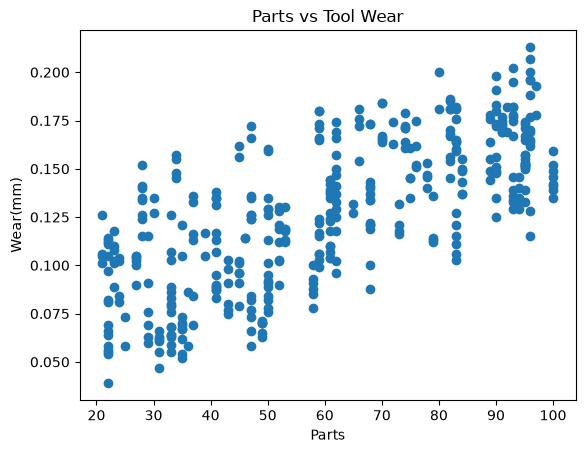

In [205]:
plt.scatter(analysis_df["parts"],analysis_df["wear_mm"])
plt.xlabel("Parts")
plt.ylabel("Wear(mm)")
plt.title("Parts vs Tool Wear")
plt.show()

In [206]:
analysis_df["cutting_time"].corr(analysis_df["wear_mm"])

np.float64(0.750252737440415)

### 3.2 Cutting Time vs Tool Wear

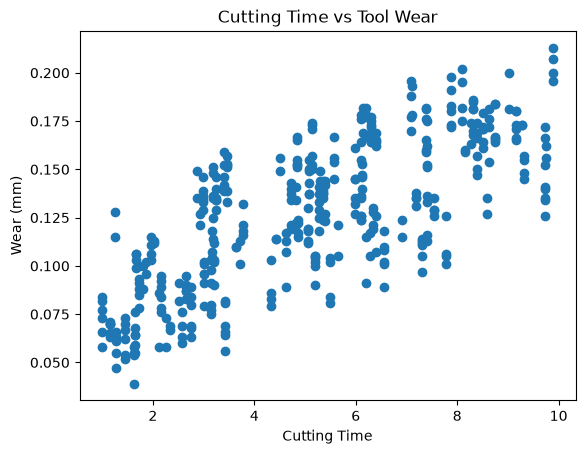

In [207]:
plt.scatter(analysis_df["cutting_time"], analysis_df["wear_mm"])
plt.xlabel("Cutting Time")
plt.ylabel("Wear (mm)")
plt.title("Cutting Time vs Tool Wear")
plt.show()

In [208]:
analysis_df["rpm"].corr(analysis_df["wear_mm"])

np.float64(0.01781731919579375)

### 3.3 RPM vs Tool Wear

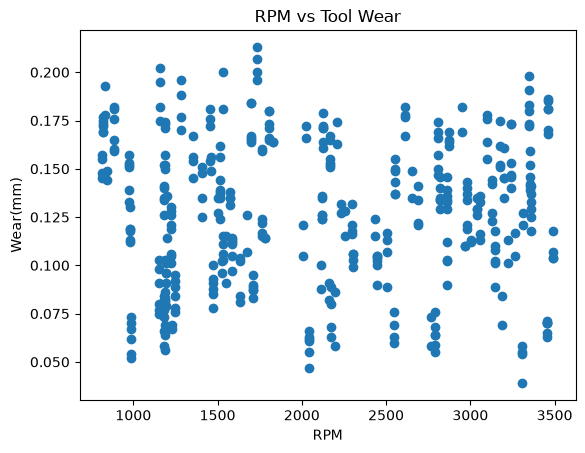

In [209]:
plt.scatter(analysis_df["rpm"],analysis_df["wear_mm"])
plt.xlabel("RPM")
plt.ylabel("Wear(mm)")
plt.title("RPM vs Tool Wear")
plt.show()

In [210]:
analysis_df.columns

Index(['measurement_id', 'position_id', 'operation_id', 'wear_mm',
       'visual_condition', 'measurement_date', 'tool_id', 'position_number',
       'work_order_id', 'machine_id', 'operator_id', 'parts', 'cutting_time',
       'rpm', 'parts_group'],
      dtype='str')

In [211]:
analysis_df["visual_condition"].value_counts()

visual_condition
Slight Whitening    300
Normal              100
Visible Wear          4
Name: count, dtype: int64

In [212]:
analysis_df.groupby("visual_condition")["wear_mm"].mean()

visual_condition
Normal              0.076010
Slight Whitening    0.142643
Visible Wear        0.205500
Name: wear_mm, dtype: float64

### 3.4 Visual Condition vs Tool Wear

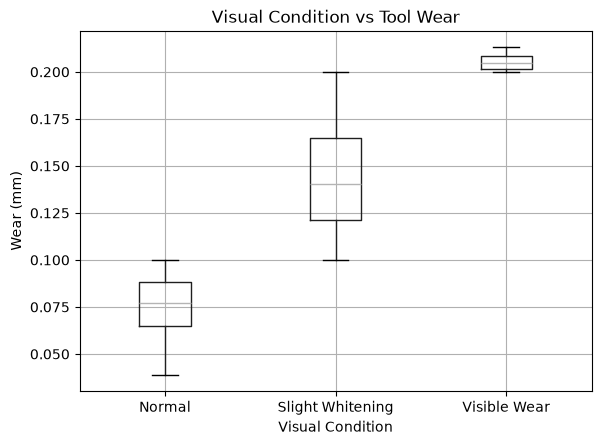

In [213]:
analysis_df.boxplot(
    column="wear_mm",
    by="visual_condition"
)

plt.xlabel("Visual Condition")
plt.ylabel("Wear (mm)")
plt.title("Visual Condition vs Tool Wear")
plt.suptitle("")
plt.show()

In [214]:
analysis_df.groupby("position_number")["wear_mm"].mean()

position_number
1    0.125593
2    0.130604
3    0.125224
4    0.125384
Name: wear_mm, dtype: float64

In [215]:
analysis_df.groupby("machine_id")["wear_mm"].mean()

machine_id
M001    0.147437
M002    0.107542
M003    0.119068
M004    0.111500
M005    0.140111
M006    0.152500
M007    0.117648
Name: wear_mm, dtype: float64

In [216]:
analysis_df["machine_id"].value_counts()

machine_id
M007    88
M001    80
M004    64
M005    54
M002    48
M003    44
M006    26
Name: count, dtype: int64

In [217]:
analysis_df.groupby("machine_id")["wear_mm"].agg(
    ["count", "mean", "std", "min", "max"]
)

,count,mean,std,min,max
machine_id,,,,,
M001,80,0.147437,0.032144,0.058,0.213
M002,48,0.107542,0.043666,0.039,0.186
M003,44,0.119068,0.039731,0.055,0.184
M004,64,0.111500,0.030837,0.047,0.182
M005,54,0.140111,0.033788,0.079,0.202
M006,26,0.152500,0.020334,0.121,0.196
M007,88,0.117648,0.033968,0.056,0.193


In [218]:
analysis_df.groupby("tool_id")["wear_mm"].agg(
    ["count", "mean", "std", "min", "max"]
)

,count,mean,std,min,max
tool_id,,,,,
T001,38,0.137421,0.034781,0.055,0.184
T002,24,0.134333,0.034913,0.070,0.207
T003,42,0.127833,0.032305,0.052,0.198
T004,36,0.132833,0.046923,0.059,0.213
T005,48,0.117708,0.038258,0.054,0.193
T006,48,0.131458,0.038869,0.047,0.195
T007,48,0.129896,0.033480,0.058,0.182
T008,36,0.122722,0.041633,0.039,0.200
T009,46,0.111783,0.034247,0.054,0.181


In [219]:
analysis_df.groupby(
    ["tool_id", "position_number"]
)["wear_mm"].mean()

tool_id  position_number
T001     1                  0.135727
         2                  0.136385
         3                  0.139714
T002     1                  0.123667
         2                  0.182000
         3                  0.126889
         4                  0.129444
T003     1                  0.130000
         2                  0.131300
         3                  0.135091
         4                  0.117692
T004     1                  0.119571
         2                  0.131667
         3                  0.147923
T005     1                  0.122867
         2                  0.120545
         3                  0.124778
         4                  0.104462
T006     1                  0.131235
         2                  0.134400
         3                  0.110333
         4                  0.138200
T007     1                  0.141818
         2                  0.131000
         3                  0.114545
         4                  0.131643
T008     1   

In [220]:
analysis_df.groupby(
    ["tool_id", "position_number"]
).size()

tool_id  position_number
T001     1                  11
         2                  13
         3                  14
T002     1                   3
         2                   3
         3                   9
         4                   9
T003     1                   8
         2                  10
         3                  11
         4                  13
T004     1                  14
         2                   9
         3                  13
T005     1                  15
         2                  11
         3                   9
         4                  13
T006     1                  17
         2                  10
         3                   6
         4                  15
T007     1                  11
         2                  12
         3                  11
         4                  14
T008     1                  13
         2                  16
         3                   7
T009     1                  17
         2                  17
         3    

In [221]:
analysis_df.groupby("operator_id")["wear_mm"].agg(
    ["count", "mean", "std", "min", "max"]
)

,count,mean,std,min,max
operator_id,,,,,
OP001,32,0.133937,0.034999,0.060,0.196
OP002,40,0.132625,0.042066,0.055,0.202
OP003,42,0.108714,0.032574,0.039,0.174
OP004,40,0.133150,0.040080,0.063,0.213
OP005,26,0.134731,0.027512,0.101,0.186
OP006,42,0.134667,0.032058,0.058,0.184
OP007,42,0.118095,0.037993,0.047,0.200
OP008,50,0.134240,0.037577,0.076,0.198
OP009,42,0.106643,0.034642,0.052,0.167


In [222]:
analysis_df[
    ["parts", "cutting_time", "rpm", "wear_mm"]
].corr()

,parts,cutting_time,rpm,wear_mm
parts,1.000000,0.132378,0.111555,0.714700
cutting_time,0.132378,1.000000,-0.047408,0.750253
rpm,0.111555,-0.047408,1.000000,0.017817
wear_mm,0.714700,0.750253,0.017817,1.000000


### 3.5 Wear Distribution

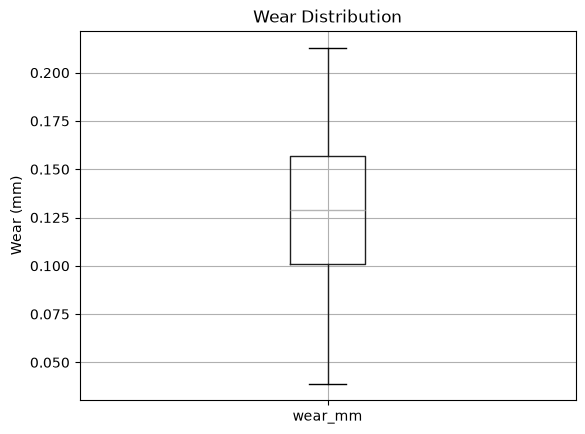

In [223]:
analysis_df.boxplot(column="wear_mm")
plt.ylabel("Wear (mm)")
plt.title("Wear Distribution")
plt.show()

In [258]:
analysis_df[["wear_mm", "wear_status"]].head(10)

,wear_mm,wear_status
0,0.100,Monitor
1,0.107,Monitor
2,0.104,Monitor
3,0.086,Normal
4,0.202,Replacement Recommend
5,0.195,Monitor
6,0.136,Monitor
7,0.182,Monitor
8,0.165,Monitor
9,0.176,Monitor


In [233]:
analysis_df["wear_status"].value_counts()

wear_status
Monitor                  301
Normal                    98
Replacement Recommend      5
Name: count, dtype: int64

In [234]:
analysis_df.groupby("wear_status")[["parts", "cutting_time", "rpm"]].mean()

,parts,cutting_time,rpm
wear_status,,,
Normal,38.418367,2.441633,1913.765306
Monitor,67.295681,5.923688,2168.950166
Replacement Recommend,92.200000,9.358000,1576.600000


In [235]:
analysis_df[
    analysis_df["wear_status"] == "Replacement Recommend"
][[
    "wear_mm",
    "parts",
    "cutting_time",
    "rpm",
    "machine_id",
    "tool_id",
    "position_number",
    "visual_condition"
]]

,wear_mm,parts,cutting_time,rpm,machine_id,tool_id,position_number,visual_condition
4,0.202,93,8.10,1160,M005,T004,2,Visible Wear
10,0.200,80,9.02,1530,M005,T008,2,Slight Whitening
141,0.213,96,9.89,1731,M001,T004,3,Visible Wear
342,0.207,96,9.89,1731,M001,T002,2,Visible Wear
343,0.200,96,9.89,1731,M001,T004,1,Visible Wear


In [236]:
pd.crosstab(
    analysis_df["visual_condition"],
    analysis_df["wear_status"]
)

wear_status,Normal,Monitor,Replacement Recommend
visual_condition,,,
Normal,98,2,0
Slight Whitening,0,299,1
Visible Wear,0,0,4


In [237]:
analysis_df.groupby("wear_status")[["parts", "cutting_time"]].agg(
    ["mean", "min", "max"]
)

parts          cutting_time            
                            mean min  max         mean   min   max
wear_status                                                       
Normal                 38.418367  22   68     2.441633  1.00  7.31
Monitor                67.295681  21  100     5.923688  1.25  9.89
Replacement Recommend  92.200000  80   96     9.358000  8.10  9.89

In [238]:
analysis_df = analysis_df.merge(
    work_orders_df[["work_order_id", "material"]],
    on="work_order_id",
    how="left"
)

In [239]:
analysis_df[["work_order_id", "material"]].head()

,work_order_id,material
0,W007,Copper
1,W006,Steel
2,W006,Steel
3,W002,Steel
4,W006,Steel


In [240]:
analysis_df.groupby("material")["wear_mm"].agg(["count","mean","min","max"])

,count,mean,min,max
material,,,,
Aliminium,40,0.122000,0.047,0.174
Copper,50,0.132580,0.060,0.193
Steel,314,0.126455,0.039,0.213


In [241]:
analysis_df = analysis_df.merge(
    tools_df[
        ["tool_id", "insert_shape", "chip_breaker"]
    ],
    on="tool_id",
    how="left"
)

In [242]:
analysis_df.groupby("insert_shape")["wear_mm"].mean()

insert_shape
Romboid       0.127629
Triangular    0.125410
Name: wear_mm, dtype: float64

In [243]:
analysis_df.groupby("chip_breaker")["wear_mm"].mean()

chip_breaker
False    0.125659
True     0.129015
Name: wear_mm, dtype: float64

In [244]:
analysis_df.groupby("chip_breaker")["wear_mm"].agg(
    ["count", "mean", "std", "min", "max"]
)

,count,mean,std,min,max
chip_breaker,,,,,
False,270,0.125659,0.036206,0.047,0.198
True,134,0.129015,0.040691,0.039,0.213


In [245]:
analysis_df = analysis_df.merge(
    work_orders_df[["work_order_id", "material"]],
    on="work_order_id",
    how="left"
)

In [246]:
analysis_df["material_x"].equals(analysis_df["material_y"])

True

In [247]:
analysis_df = analysis_df.drop(columns="material_y")
analysis_df = analysis_df.rename(columns={"material_x": "material"})

In [248]:
material_wear = analysis_df.groupby("material")["wear_mm"].mean()

### 3.6 Average Tool Wear by Material

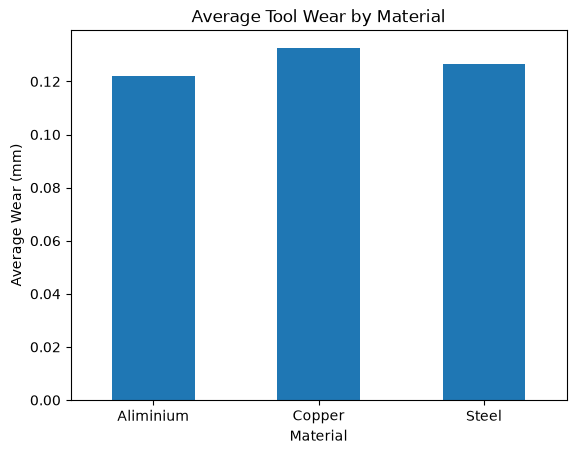

In [249]:
material_wear.plot(kind="bar")

plt.xlabel("Material")
plt.ylabel("Average Wear (mm)")
plt.title("Average Tool Wear by Material")
plt.xticks(rotation=0)

plt.show()

In [250]:
analysis_df[
    ["wear_mm", "wear_status", "recommended_action"]
].head(10)

,wear_mm,wear_status,recommended_action
0,0.100,Monitor,Monitor Tool
1,0.107,Monitor,Monitor Tool
2,0.104,Monitor,Monitor Tool
3,0.086,Normal,Continue Production
4,0.202,Replacement Recommend,Replace Tool
5,0.195,Monitor,Monitor Tool
6,0.136,Monitor,Monitor Tool
7,0.182,Monitor,Monitor Tool
8,0.165,Monitor,Monitor Tool
9,0.176,Monitor,Monitor Tool


In [251]:
replacement_df.head()

,measurement_id,tool_id,position_number,machine_id,parts,cutting_time,rpm,wear_mm,visual_condition,recommended_action
4,5,T004,2,M005,93,8.10,1160,0.202,Visible Wear,Replace Tool
10,11,T008,2,M005,80,9.02,1530,0.200,Slight Whitening,Replace Tool
141,142,T004,3,M001,96,9.89,1731,0.213,Visible Wear,Replace Tool
342,343,T002,2,M001,96,9.89,1731,0.207,Visible Wear,Replace Tool
343,344,T004,1,M001,96,9.89,1731,0.200,Visible Wear,Replace Tool


In [252]:
replacement_df = replacement_df[[
    "measurement_id",
    "tool_id",
    "position_number",
    "machine_id",
    "parts",
    "cutting_time",
    "rpm",
    "wear_mm",
    "visual_condition",
    "recommended_action"
]]

In [253]:
replacement_df = analysis_df[
    analysis_df["wear_status"] == "Replacement Recommend"
]

In [254]:
replacement_df = replacement_df[[
    "measurement_id",
    "tool_id",
    "position_number",
    "machine_id",
    "parts",
    "cutting_time",
    "rpm",
    "wear_mm",
    "visual_condition",
    "wear_status",
    "recommended_action"
]]

In [255]:
replacement_df.head()

,measurement_id,tool_id,position_number,machine_id,parts,cutting_time,rpm,wear_mm,visual_condition,wear_status,recommended_action
4,5,T004,2,M005,93,8.10,1160,0.202,Visible Wear,Replacement Recommend,Replace Tool
10,11,T008,2,M005,80,9.02,1530,0.200,Slight Whitening,Replacement Recommend,Replace Tool
141,142,T004,3,M001,96,9.89,1731,0.213,Visible Wear,Replacement Recommend,Replace Tool
342,343,T002,2,M001,96,9.89,1731,0.207,Visible Wear,Replacement Recommend,Replace Tool
343,344,T004,1,M001,96,9.89,1731,0.200,Visible Wear,Replacement Recommend,Replace Tool


In [256]:
analysis_df.columns

Index(['measurement_id', 'position_id', 'operation_id', 'wear_mm',
       'visual_condition', 'measurement_date', 'tool_id', 'position_number',
       'work_order_id', 'machine_id', 'operator_id', 'parts', 'cutting_time',
       'rpm', 'parts_group', 'wear_status', 'recommended_action', 'material',
       'insert_shape', 'chip_breaker'],
      dtype='str')

In [257]:
analysis_df.to_csv("analysis_data.csv", index=False)

## 4. Wear Classification

In [225]:
bins = [0, 0.10, 0.20, float("inf")]
labels=["Normal","Monitor","Replacement Recommend"]

In [226]:
analysis_df["wear_status"] = pd.cut(
    analysis_df["wear_mm"],
    bins=bins,
    labels=labels,
    right=False
)

In [227]:
analysis_df.groupby("wear_status")["wear_mm"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
wear_status,,,,
Normal,98,0.075520,0.039,0.099
Monitor,301,0.142169,0.100,0.198
Replacement Recommend,5,0.204400,0.200,0.213


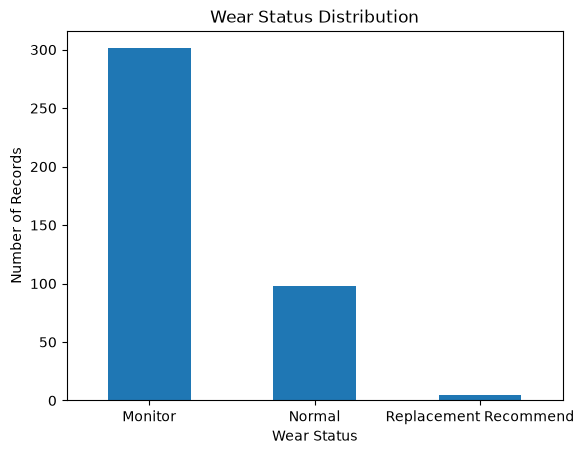

In [228]:
analysis_df["wear_status"].value_counts().plot(kind="bar")

plt.xlabel("Wear Status")
plt.ylabel("Number of Records")
plt.title("Wear Status Distribution")
plt.xticks(rotation=0)
plt.show()

## 5. Decision Support

In [229]:
action_map = {
    "Normal": "Continue Production",
    "Monitor": "Monitor Tool",
    "Replacement Recommend": "Replace Tool"
}

analysis_df["recommended_action"] = (
    analysis_df["wear_status"].map(action_map)
)

In [230]:
analysis_df[ ["tool_id", "position_number","wear_mm","wear_status","recommended_action" ]].head()

,tool_id,position_number,wear_mm,wear_status,recommended_action
0,T008,2,0.100,Monitor,Monitor Tool
1,T001,2,0.107,Monitor,Monitor Tool
2,T007,2,0.104,Monitor,Monitor Tool
3,T007,3,0.086,Normal,Continue Production
4,T004,2,0.202,Replacement Recommend,Replace Tool


## 6. Replacement Recommendations

In [231]:
replacement_df = analysis_df[
    analysis_df["wear_status"] == "Replacement Recommend"
][[
    "measurement_id",
    "tool_id",
    "position_number",
    "machine_id",
    "parts",
    "cutting_time",
    "rpm",
    "wear_mm",
    "visual_condition",
    "recommended_action"
]]

In [232]:
replacement_df.head()

,measurement_id,tool_id,position_number,machine_id,parts,cutting_time,rpm,wear_mm,visual_condition,recommended_action
4,5,T004,2,M005,93,8.10,1160,0.202,Visible Wear,Replace Tool
10,11,T008,2,M005,80,9.02,1530,0.200,Slight Whitening,Replace Tool
141,142,T004,3,M001,96,9.89,1731,0.213,Visible Wear,Replace Tool
342,343,T002,2,M001,96,9.89,1731,0.207,Visible Wear,Replace Tool
343,344,T004,1,M001,96,9.89,1731,0.200,Visible Wear,Replace Tool
